In [2]:
# Etap 1: Analiza przypadku klinicznego (na podstawie danych)

import pandas as pd

DATA_PATH = "cases_clinical_for_lab12.csv"
df = pd.read_csv(DATA_PATH)

TARGET_COL = "high_risk_cvd"

if TARGET_COL not in df.columns:
    raise ValueError(f"Brak kolumny target: {TARGET_COL}. Dostępne kolumny: {list(df.columns)}")

NUM_COLS = [c for c in ["age", "bmi", "systolic_bp", "diastolic_bp", "glucose"] if c in df.columns]
CAT_COLS = [c for c in ["sex", "smoker", "family_history"] if c in df.columns]
FEATURE_COLS = [c for c in (NUM_COLS + CAT_COLS) if c != TARGET_COL]

THRESHOLDS = [0.5, 0.4]  # wariant 12: wpływ tau na FP/FN będzie analizowany później

print("Etap 1: problem predykcyjny")
print(f"- Typ: klasyfikacja binarna")
print(f"- Target: {TARGET_COL} (wartości: {sorted(df[TARGET_COL].dropna().unique().tolist())})")
print(f"- Liczba obserwacji: {len(df)}")
print(f"- Cechy numeryczne: {NUM_COLS}")
print(f"- Cechy kategoryczne: {CAT_COLS}")
print(f"- Wszystkie cechy (bez targetu): {FEATURE_COLS}")

print("\nSzybki podgląd rozkładu targetu:")
print(df[TARGET_COL].value_counts(dropna=False))


Etap 1: problem predykcyjny
- Typ: klasyfikacja binarna
- Target: high_risk_cvd (wartości: [0, 1])
- Liczba obserwacji: 1000
- Cechy numeryczne: ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'glucose']
- Cechy kategoryczne: ['sex', 'smoker', 'family_history']
- Wszystkie cechy (bez targetu): ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'glucose', 'sex', 'smoker', 'family_history']

Szybki podgląd rozkładu targetu:
high_risk_cvd
1    661
0    339
Name: count, dtype: int64


In [3]:
# Etap 2: Przygotowanie danych

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Dane są już wczytane w Etapie 1 jako df

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Podział cech
X_num = X[NUM_COLS]
X_cat = X[CAT_COLS]

# Imputacja braków danych
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_num_imp = pd.DataFrame(
    num_imputer.fit_transform(X_num),
    columns=NUM_COLS,
    index=X.index
)

X_cat_imp = pd.DataFrame(
    cat_imputer.fit_transform(X_cat),
    columns=CAT_COLS,
    index=X.index
)

# Kodowanie zmiennych kategorycznych
X_cat_enc = pd.get_dummies(X_cat_imp, drop_first=True)

# Standaryzacja cech numerycznych
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_num_imp),
    columns=NUM_COLS,
    index=X.index
)

# Połączenie cech
X_prepared = pd.concat([X_num_scaled, X_cat_enc], axis=1)

print("Etap 2: przygotowanie danych")
print(f"- Kształt macierzy cech: {X_prepared.shape}")
print(f"- Liczba cech po kodowaniu: {X_prepared.shape[1]}")
print(f"- Braki danych po preprocessingu: {X_prepared.isna().sum().sum()}")

X_prepared.head()


Etap 2: przygotowanie danych
- Kształt macierzy cech: (1000, 8)
- Liczba cech po kodowaniu: 8
- Braki danych po preprocessingu: 0


,age,bmi,systolic_bp,diastolic_bp,glucose,sex_M,smoker_yes,family_history_yes
0,1.309286,1.216218,-1.249182,0.161325,0.462117,True,False,False
1,-1.526331,-0.886824,-1.479075,-1.432631,-0.119223,False,False,True
2,-0.372860,-0.866206,-0.272136,-1.348738,1.091902,True,False,True
3,-0.180614,0.515204,-1.191708,-1.348738,-0.652118,True,False,False
4,1.020918,1.216218,-0.674449,0.580787,1.091902,False,True,False


Etap 3: statystyki opisowe (cechy numeryczne)


,count,mean,std,min,25%,50%,75%,max
age,1000.0,53.7580,20.817175,18.0,36.0,53.0,72.0,89.0
bmi,1000.0,25.8012,4.852544,16.0,22.5,25.9,28.8,40.6
systolic_bp,1000.0,130.7350,17.408096,90.0,119.0,130.0,143.0,187.0
diastolic_bp,1000.0,82.0770,11.925993,50.0,74.0,82.0,89.0,123.0
glucose,1000.0,100.4610,20.652288,60.0,86.0,100.0,114.0,165.0



Etap 3: rozkład targetu


,count
high_risk_cvd,
1,661
0,339


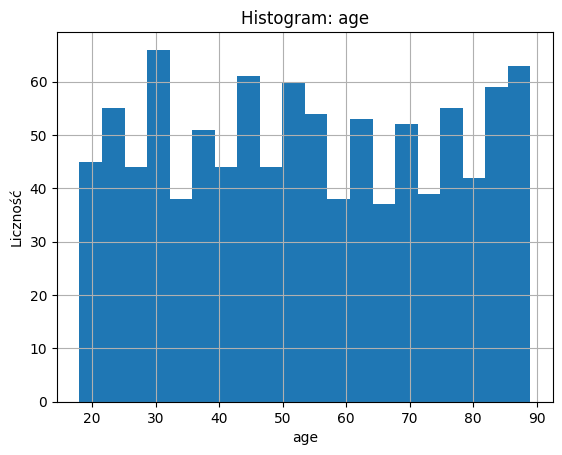

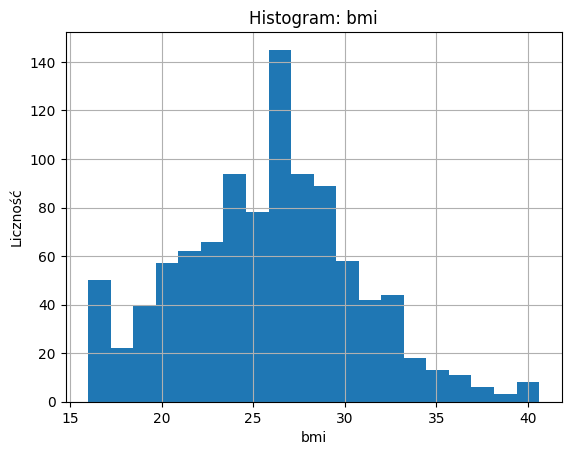

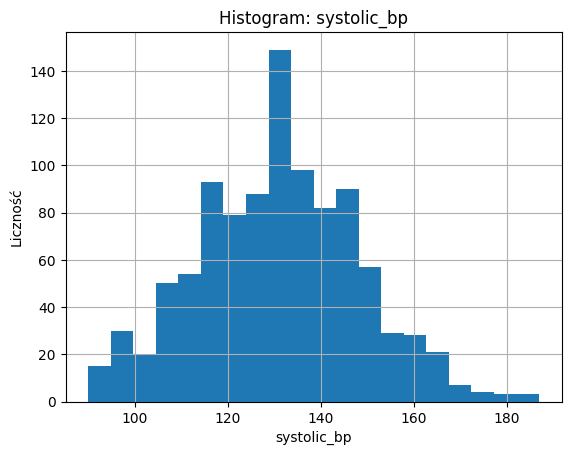

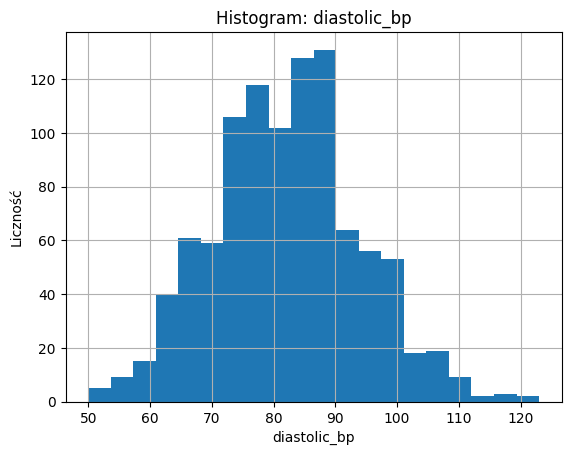

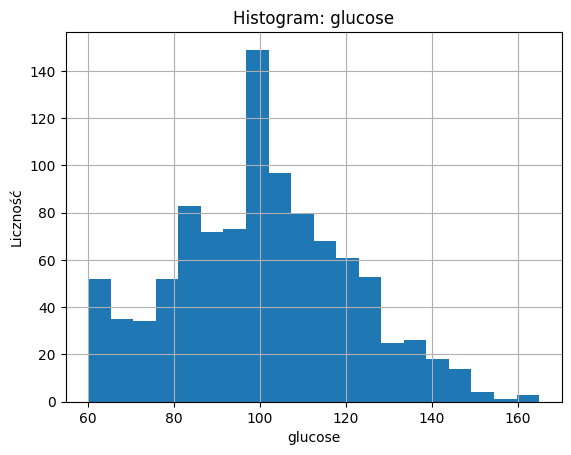

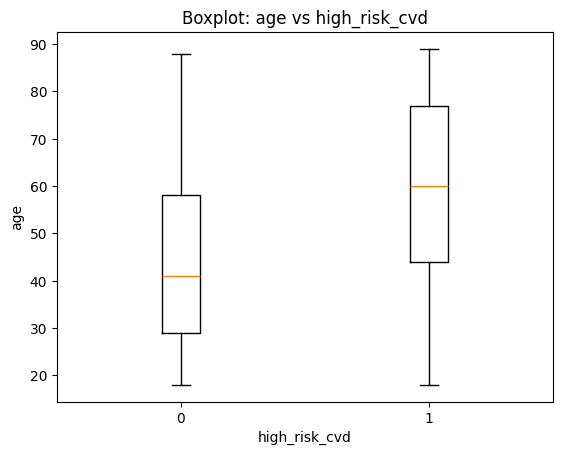

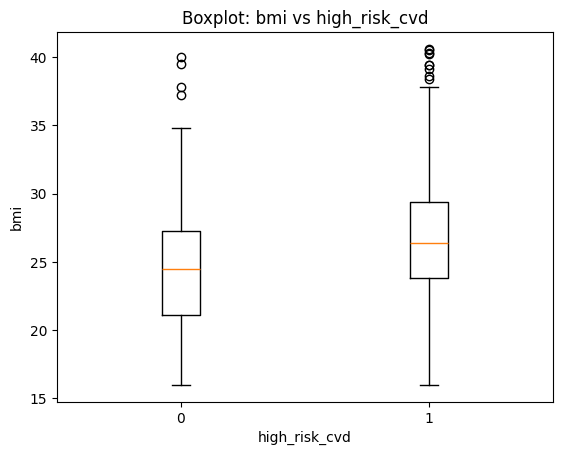

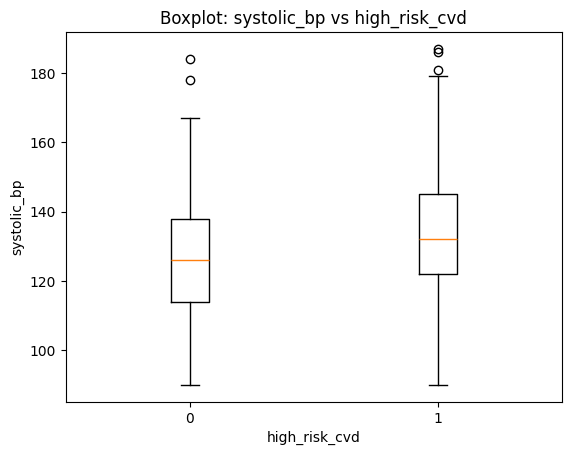

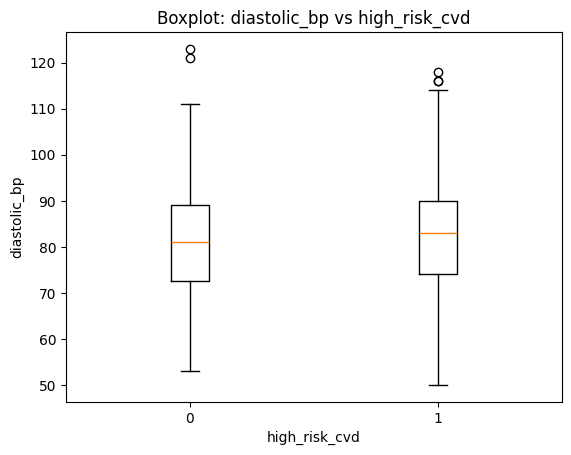

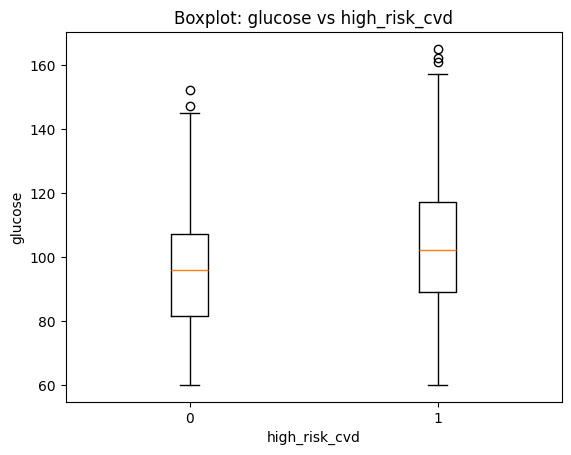


Etap 3: zależności cech numerycznych z targetem (średnie w grupach)


high_risk_cvd,0,1
age,44.383481,58.565809
bmi,24.351622,26.544629
systolic_bp,125.569322,133.384266
diastolic_bp,80.828909,82.717095
glucose,95.076696,103.222390



Etap 3: zależności cech kategorycznych z targetem (tabele częstości i odsetki)

Cecha: sex
Częstości:


high_risk_cvd,0,1,All
sex,,,
F,190,333,523
M,149,328,477
All,339,661,1000


Odsetki w ramach kategorii (%):


...

high_risk_cvd,0,1
smoker,,
no,36.29,63.71
yes,28.33,71.67



Cecha: family_history
Częstości:


high_risk_cvd,0,1,All
family_history,,,
no,234,426,660
yes,105,235,340
All,339,661,1000


Odsetki w ramach kategorii (%):


high_risk_cvd,0,1
family_history,,
no,35.45,64.55
yes,30.88,69.12


In [4]:
# Etap 3: Analiza eksploracyjna (EDA)

import matplotlib.pyplot as plt

# Dane do EDA po imputacji (bez standaryzacji dla czytelności)
df_eda = pd.concat([X_num_imp, X_cat_imp, y.rename(TARGET_COL)], axis=1)

print("Etap 3: statystyki opisowe (cechy numeryczne)")
display(df_eda[NUM_COLS].describe().T)

print("\nEtap 3: rozkład targetu")
display(df_eda[TARGET_COL].value_counts().to_frame("count"))

# Histogramy cech numerycznych
for col in NUM_COLS:
    plt.figure()
    df_eda[col].hist(bins=20)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Liczność")
    plt.show()

# Wykresy pudełkowe cech numerycznych względem targetu
for col in NUM_COLS:
    plt.figure()
    data0 = df_eda.loc[df_eda[TARGET_COL] == 0, col].values
    data1 = df_eda.loc[df_eda[TARGET_COL] == 1, col].values
    plt.boxplot([data0, data1], labels=["0", "1"])
    plt.title(f"Boxplot: {col} vs {TARGET_COL}")
    plt.xlabel(TARGET_COL)
    plt.ylabel(col)
    plt.show()

print("\nEtap 3: zależności cech numerycznych z targetem (średnie w grupach)")
num_group_means = df_eda.groupby(TARGET_COL)[NUM_COLS].mean().T
display(num_group_means)

print("\nEtap 3: zależności cech kategorycznych z targetem (tabele częstości i odsetki)")
for col in CAT_COLS:
    ct = pd.crosstab(df_eda[col], df_eda[TARGET_COL], margins=True)
    pct = pd.crosstab(df_eda[col], df_eda[TARGET_COL], normalize="index") * 100
    print(f"\nCecha: {col}")
    print("Częstości:")
    display(ct)
    print("Odsetki w ramach kategorii (%):")
    display(pct.round(2))


In [6]:
# Etap 4: Budowa modelu predykcyjnego

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Etap 4: podział danych")
print(f"- Zbiór treningowy: {X_train.shape}")
print(f"- Zbiór testowy: {X_test.shape}")

# Model: regresja logistyczna
model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

# Trening modelu
model.fit(X_train, y_train)

print("Etap 4: trening modelu zakończony")

# Współczynniki modelu
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df


Etap 4: podział danych
- Zbiór treningowy: (700, 8)
- Zbiór testowy: (300, 8)
Etap 4: trening modelu zakończony


,feature,coefficient
0,age,0.828422
6,smoker_yes,0.533806
4,glucose,0.517838
1,bmi,0.470416
2,systolic_bp,0.449050
7,family_history_yes,0.291365
5,sex_M,0.172061
3,diastolic_bp,0.070487


Etap 5: metryki dla różnych progów tau


,tau,accuracy,precision,recall,roc_auc,tn,fp,fn,tp
1,0.4,0.703333,0.718876,0.904040,0.737621,32,70,19,179
0,0.5,0.730000,0.767123,0.848485,0.737621,51,51,30,168


ROC AUC (na prawdopodobieństwach): 0.7376213111507228


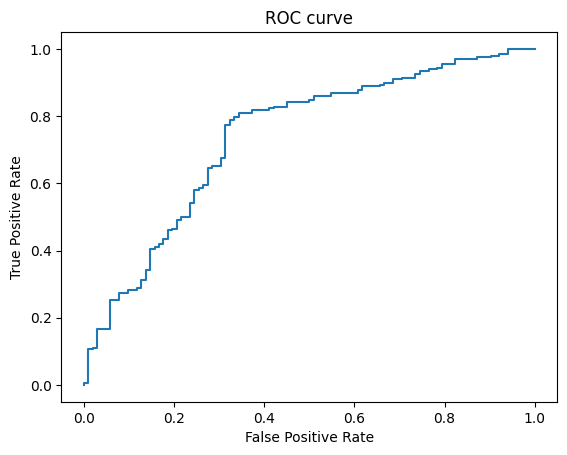

Confusion matrix dla tau = 0.5


,pred_0,pred_1
true_0,51,51
true_1,30,168


Confusion matrix dla tau = 0.4


,pred_0,pred_1
true_0,32,70
true_1,19,179


Etap 5: analiza przypadków dla tau = 0.5
FP: 3 przypadki (false positives)


...

,age,bmi,systolic_bp,diastolic_bp,glucose,sex,smoker,family_history,y_true,y_pred,p_hat,distance
773,68.0,34.5,148.0,100.0,147.0,M,no,no,0,1,0.979275,0.000000
72,46.0,30.8,136.0,99.0,141.0,M,no,no,1,1,0.896091,1.505702
835,57.0,30.8,143.0,88.0,133.0,M,no,no,1,1,0.924660,1.554832
26,62.0,30.8,134.0,92.0,138.0,F,no,no,1,1,0.920652,1.718451
309,56.0,40.2,148.0,93.0,138.0,F,no,no,1,1,0.970439,1.802428
716,49.0,28.4,147.0,87.0,147.0,M,no,no,1,1,0.917181,1.899578


Analiza FN + sąsiedzi: row_id = 128


,row_id,distance
377,377,1.304965
311,311,1.362555
514,514,1.364400
254,254,1.441886
584,584,1.463303


,age,bmi,systolic_bp,diastolic_bp,glucose,sex,smoker,family_history,y_true,y_pred,p_hat,distance
128,22.0,20.2,130.0,72.0,62.0,F,yes,no,1,0,0.146321,0.000000
377,27.0,24.0,134.0,80.0,77.0,F,yes,no,1,0,0.338661,1.304965
311,22.0,25.5,141.0,66.0,60.0,F,yes,no,0,0,0.258945,1.362555
514,25.0,18.5,130.0,73.0,89.0,F,yes,no,1,0,0.244912,1.364400
254,39.0,20.6,126.0,72.0,86.0,F,yes,no,0,0,0.366039,1.441886
584,43.0,18.9,132.0,70.0,60.0,M,yes,no,0,0,0.290688,1.463303


Interpretacja kliniczna (tekst do raportu):
Model zwraca prawdopodobieństwo wysokiego ryzyka CVD. Zmiana progu tau wpływa na kompromis między FP i FN. Niższy próg zwykle zwiększa czułość (Recall) kosztem większej liczby FP, a wyższy próg zwykle zmniejsza FP kosztem większej liczby FN. W kontekście klinicznym wybór tau zależy od tego, czy ważniejsze jest wyłapanie jak największej liczby pacjentów wysokiego ryzyka (mniej FN), czy ograniczenie niepotrzebnych alarmów (mniej FP).

Ograniczenia modelu (tekst do raportu):
Ograniczenia: dane mogą być małe i obciążone biasem, model jest liniowy i może nie uchwycić relacji nieliniowych, imputacja i kodowanie mogą wprowadzać uproszczenia, a metryki zależą od rozkładu klas. Model nie uwzględnia historii chorób ani leków, jeśli nie ma ich w danych. Wyniki nie są narzędziem diagnostycznym.


In [8]:
# Etap 5: Ewaluacja i interpretacja (wariant 12: progi tau + analiza FP/FN + podobne przypadki)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve
)

def predict_with_threshold(model, X, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    return y_pred, proba

def metrics_report(y_true, y_pred, y_proba):
    out = {}
    out["accuracy"] = float(accuracy_score(y_true, y_pred))
    out["precision"] = float(precision_score(y_true, y_pred, zero_division=0))
    out["recall"] = float(recall_score(y_true, y_pred, zero_division=0))
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, y_proba))
    except ValueError:
        out["roc_auc"] = np.nan
    return out

def confusion_as_df(cm):
    return pd.DataFrame(
        cm,
        index=["true_0", "true_1"],
        columns=["pred_0", "pred_1"]
    )

def error_cases_df(X_orig_eda, X_prepared_full, y_true, y_pred, y_proba, case_type, top_n=3):
    if case_type == "FP":
        mask = (y_true.values == 0) & (y_pred == 1)
        sort_ascending = False
    elif case_type == "FN":
        mask = (y_true.values == 1) & (y_pred == 0)
        sort_ascending = True
    else:
        raise ValueError("case_type must be 'FP' or 'FN'")

    idx = y_true.index[mask]
    if len(idx) == 0:
        return pd.DataFrame()

    df_cases = X_orig_eda.loc[idx, FEATURE_COLS].copy()
    df_cases["y_true"] = y_true.loc[idx].values
    df_cases["y_pred"] = y_pred[mask]
    df_cases["p_hat"] = y_proba[mask]
    df_cases["row_id"] = idx

    df_cases = df_cases.sort_values("p_hat", ascending=sort_ascending).head(top_n)
    return df_cases

def nearest_neighbors(case_row_id, X_prepared_full, k=5):
    if case_row_id not in X_prepared_full.index:
        raise ValueError("case_row_id not found in X_prepared_full index")

    X_float = X_prepared_full.astype(float)

    x0 = X_float.loc[case_row_id].values.reshape(1, -1)
    X_all = X_float.values
    idx_all = X_float.index.values

    dists = np.sqrt(((X_all - x0) ** 2).sum(axis=1))

    nn = pd.DataFrame({
        "row_id": idx_all,
        "distance": dists
    }).sort_values("distance")

    nn = nn[nn["row_id"] != case_row_id].head(k)
    return nn

def show_neighbor_comparison(case_row_id, nn_df, df_eda_full, y_true_full, y_pred_full, y_proba_full):
    rows = [case_row_id] + nn_df["row_id"].tolist()
    out = df_eda_full.loc[rows, FEATURE_COLS].copy()

    out["y_true"] = y_true_full.loc[rows].values
    out["y_pred"] = y_pred_full.loc[rows].values
    out["p_hat"] = y_proba_full.loc[rows].values

    dist_map = {case_row_id: 0.0}
    dist_map.update(dict(zip(nn_df["row_id"].values, nn_df["distance"].values)))
    out["distance"] = [dist_map[r] for r in rows]

    return out

# Przygotowanie pomocniczych ramek do analizy przypadków:
# df_eda jest z Etapu 3 (imputowane, nieskalowane wartości dla czytelności)
df_eda_full = df_eda.copy()

# Predykcje bazowe (progi tau)
results = []
pred_store = {}

for tau in THRESHOLDS:
    y_pred_tau, y_proba_tau = predict_with_threshold(model, X_test, threshold=tau)
    rep = metrics_report(y_test, y_pred_tau, y_proba_tau)
    cm = confusion_matrix(y_test, y_pred_tau)

    results.append({
        "tau": tau,
        **rep,
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    })

    pred_store[tau] = {
        "y_pred": y_pred_tau,
        "y_proba": y_proba_tau,
        "cm": cm
    }

results_df = pd.DataFrame(results).sort_values("tau")
print("Etap 5: metryki dla różnych progów tau")
display(results_df)

# ROC AUC liczony na prawdopodobieństwach (nie zależy od tau)
y_proba_default = model.predict_proba(X_test)[:, 1]
try:
    roc_auc = roc_auc_score(y_test, y_proba_default)
except ValueError:
    roc_auc = np.nan

print(f"ROC AUC (na prawdopodobieństwach): {roc_auc}")

# Wykres ROC
if not np.isnan(roc_auc):
    fpr, tpr, _ = roc_curve(y_test, y_proba_default)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.title("ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

# Macierze pomyłek dla progów
for tau in THRESHOLDS:
    print(f"Confusion matrix dla tau = {tau}")
    display(confusion_as_df(pred_store[tau]["cm"]))

# Analiza błędów FP/FN + podobne przypadki (wariant 12)
# Wybieramy próg referencyjny (pierwszy z listy)
tau_ref = THRESHOLDS[0]

y_pred_ref = pred_store[tau_ref]["y_pred"]
y_proba_ref = pred_store[tau_ref]["y_proba"]

# Indeksy testowe (ważne do mapowania na df_eda_full)
test_index = X_test.index
y_test_indexed = y_test.loc[test_index]

# Tworzymy wektory y_pred i y_proba w indeksie testowym
y_pred_series = pd.Series(y_pred_ref, index=test_index, name="y_pred")
y_proba_series = pd.Series(y_proba_ref, index=test_index, name="p_hat")

print(f"Etap 5: analiza przypadków dla tau = {tau_ref}")

fp_cases = error_cases_df(df_eda_full, X_prepared, y_test_indexed, y_pred_ref, y_proba_ref, "FP", top_n=3)
fn_cases = error_cases_df(df_eda_full, X_prepared, y_test_indexed, y_pred_ref, y_proba_ref, "FN", top_n=3)

print("FP: 3 przypadki (false positives)")
display(fp_cases)

print("FN: 3 przypadki (false negatives)")
display(fn_cases)

# Dobór podobnych przypadków dla jednego FP i jednego FN (jeśli istnieją)
def analyze_one_case(case_row_id, label):
    print(f"{label}: row_id = {case_row_id}")
    nn = nearest_neighbors(case_row_id, X_prepared, k=5)
    display(nn)

    y_pred_full = pd.Series(model.predict(X_prepared), index=X_prepared.index)
    y_proba_full = pd.Series(model.predict_proba(X_prepared)[:, 1], index=X_prepared.index)

    comp = show_neighbor_comparison(
        case_row_id,
        nn,
        df_eda_full,
        y.loc[X_prepared.index],
        y_pred_full,
        y_proba_full
    )
    display(comp)

if not fp_cases.empty:
    analyze_one_case(int(fp_cases.iloc[0]["row_id"]), "Analiza FP + sąsiedzi")

if not fn_cases.empty:
    analyze_one_case(int(fn_cases.iloc[0]["row_id"]), "Analiza FN + sąsiedzi")

# Interpretacja kliniczna i ograniczenia (zwięzła forma w zmiennych tekstowych do raportu)
clinical_interpretation = (
    "Model zwraca prawdopodobieństwo wysokiego ryzyka CVD. Zmiana progu tau wpływa na kompromis między FP i FN. "
    "Niższy próg zwykle zwiększa czułość (Recall) kosztem większej liczby FP, a wyższy próg zwykle zmniejsza FP "
    "kosztem większej liczby FN. W kontekście klinicznym wybór tau zależy od tego, czy ważniejsze jest "
    "wyłapanie jak największej liczby pacjentów wysokiego ryzyka (mniej FN), czy ograniczenie niepotrzebnych alarmów (mniej FP)."
)

model_limitations = (
    "Ograniczenia: dane mogą być małe i obciążone biasem, model jest liniowy i może nie uchwycić relacji nieliniowych, "
    "imputacja i kodowanie mogą wprowadzać uproszczenia, a metryki zależą od rozkładu klas. "
    "Model nie uwzględnia historii chorób ani leków, jeśli nie ma ich w danych. Wyniki nie są narzędziem diagnostycznym."
)

print("Interpretacja kliniczna (tekst do raportu):")
print(clinical_interpretation)
print("\nOgraniczenia modelu (tekst do raportu):")
print(model_limitations)
